### Рубежный контроль №2
#### Ковалев Андрей ИУ5-63Б

In [285]:
import pandas as pd
import numpy as np
import graphviz
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.tree import export_graphviz
from io import StringIO 
from operator import itemgetter
from joblib import Parallel, delayed
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

#### Функции для дальнейшей отрисовки деревьев решений

In [286]:
def draw_feature_importances(tree_model, X_dataset, figsize=(10,5)):
    list_to_sort = list(zip(X_dataset.columns.values, tree_model.feature_importances_))
    sorted_list = sorted(list_to_sort, key=itemgetter(1), reverse = True)
    labels = [x for x,_ in sorted_list]
    data = [x for _,x in sorted_list]
    fig, ax = plt.subplots(figsize=figsize)
    ind = np.arange(len(labels))
    plt.bar(ind, data)
    plt.xticks(ind, labels, rotation='vertical')
    for a,b in zip(ind, data):
        plt.text(a-0.05, b+0.01, str(round(b,3)))
    plt.show()
    return labels, data

def render_png_tree(tree_model_param, feature_names_param, file_name, directory):
    dot_data = StringIO()
    export_graphviz(tree_model_param, out_file=dot_data, feature_names=feature_names_param,
                    filled=True, rounded=True, special_characters=True)
    graph = graphviz.Source(dot_data.getvalue())
    graph.render(directory=directory, filename=file_name, format='png', view=False)
    
def render_png_trees(random_tree_estimators, columns, file_start_num, directory):
    for i in range(len(random_tree_estimators)):
        render_png_tree(random_tree_estimators[i], 
                        columns, f"random_tree_{i+file_start_num}", 
                        directory)

#### Загрузка и первичный анализ данных

In [287]:
bookings = pd.read_csv('hotel_bookings.csv', sep=",")
print('Кол-во строк: ', bookings.shape[0],'\n' ,'Кол-во столбцов: ', bookings.shape[1], sep = '')
print(bookings.dtypes)
print('Пропуски по столбцам:', bookings.isnull().sum())
bookings.head(8)

Кол-во строк: 119390
Кол-во столбцов: 32
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03


#### Выбор признаков и кодирование категориальных.
1. Были выбраны признаки, предположительно коррелирующие с отменой брони (is_cancelled).
2. Также на основе выбранных столбцов были созданы новые:
- nights = stays_in_weekend_nights + stays_in_week_nights
- cancellation_percent = previous_cancellations / (previous_bookings_not_canceled + previous_cancellations)

In [288]:

bookings_nec = bookings[["arrival_date_month", "is_canceled", "lead_time", "distribution_channel", 
                         "is_repeated_guest", "previous_cancellations", "previous_bookings_not_canceled", 
                         "deposit_type", "customer_type", "days_in_waiting_list", "stays_in_weekend_nights",
                         "stays_in_week_nights"]]

month_codes_dict = {"January": 1, "February": 2, "March": 3, "April": 4, 
                        "May": 5, "June": 6, "July": 7, "August": 8,
                        "September": 9, "October": 10, "November": 11, "December": 12}

def make_new_columns_outer(bookings_nec):
    return bookings_nec.apply(make_new_columns_inner, axis=1)

def make_new_columns_inner(row):
    month_str = month_codes_dict[row["arrival_date_month"]]
    nights = row["stays_in_weekend_nights"] + row["stays_in_week_nights"]
    prev_bookings_not_canceled = row["previous_bookings_not_canceled"]
    prev_cancellations = row["previous_cancellations"]
    cancellation_percent = 0

    if prev_bookings_not_canceled + prev_cancellations != 0:
        cancellation_percent = prev_cancellations / (
            prev_cancellations + prev_bookings_not_canceled)
    
    row["arrival_month"] = month_str
    row["nights"] = nights
    row["cancellation_percent"] = cancellation_percent

    return row


n_jobs = 8
bookings_partitions = []
n_rows = bookings_nec.shape[0]
for i in range(n_jobs):
    if i == n_jobs - 1:
        bookings_partitions.append(bookings_nec.loc[i*n_rows//n_jobs:n_rows].copy())
    elif i == 0:
        bookings_partitions.append(bookings_nec.loc[:(i+1)*n_rows//n_jobs].copy())
    else:
        bookings_partitions.append(bookings_nec.loc[i*n_rows//n_jobs:(i+1)*n_rows//n_jobs].copy())

bookings_nec = Parallel(n_jobs=n_jobs)(delayed(make_new_columns_outer)
                                       (bookings_part) for bookings_part in bookings_partitions)
bookings_nec = pd.concat(bookings_nec, axis=0)
bookings_nec = bookings_nec.drop(["arrival_date_month", "stays_in_weekend_nights", 
                                  "stays_in_week_nights", "previous_cancellations",
                                  "previous_bookings_not_canceled"], axis=1)
display(bookings_nec.head(8))


,is_canceled,lead_time,distribution_channel,is_repeated_guest,deposit_type,customer_type,days_in_waiting_list,arrival_month,nights,cancellation_percent
0,0,342,Direct,0,No Deposit,Transient,0,7,0,0.0
1,0,737,Direct,0,No Deposit,Transient,0,7,0,0.0
2,0,7,Direct,0,No Deposit,Transient,0,7,1,0.0
3,0,13,Corporate,0,No Deposit,Transient,0,7,1,0.0
4,0,14,TA/TO,0,No Deposit,Transient,0,7,2,0.0
5,0,14,TA/TO,0,No Deposit,Transient,0,7,2,0.0
6,0,0,Direct,0,No Deposit,Transient,0,7,2,0.0
7,0,9,Direct,0,No Deposit,Transient,0,7,2,0.0


In [289]:
encoding_categories = ['distribution_channel', 'deposit_type', 'customer_type']
for encoding_category in encoding_categories:
    print('Столбец:', encoding_category)
    cat_enc = pd.DataFrame({'c1':bookings_nec[encoding_category]})
    print(cat_enc['c1'].unique())
    le = LabelEncoder()
    cat_enc_le = le.fit_transform(cat_enc['c1'])
    print(np.unique(cat_enc_le))
    bookings_nec[encoding_category] = cat_enc_le   
display(bookings_nec.head(8))

Столбец: distribution_channel
['Direct' 'Corporate' 'TA/TO' 'Undefined' 'GDS']
[0 1 2 3 4]
Столбец: deposit_type
['No Deposit' 'Refundable' 'Non Refund']
[0 1 2]
Столбец: customer_type
['Transient' 'Contract' 'Transient-Party' 'Group']
[0 1 2 3]


,is_canceled,lead_time,distribution_channel,is_repeated_guest,deposit_type,customer_type,days_in_waiting_list,arrival_month,nights,cancellation_percent
0,0,342,1,0,0,2,0,7,0,0.0
1,0,737,1,0,0,2,0,7,0,0.0
2,0,7,1,0,0,2,0,7,1,0.0
3,0,13,0,0,0,2,0,7,1,0.0
4,0,14,3,0,0,2,0,7,2,0.0
5,0,14,3,0,0,2,0,7,2,0.0
6,0,0,1,0,0,2,0,7,2,0.0
7,0,9,1,0,0,2,0,7,2,0.0


#### Построение матрицы корреляции

<Axes: >

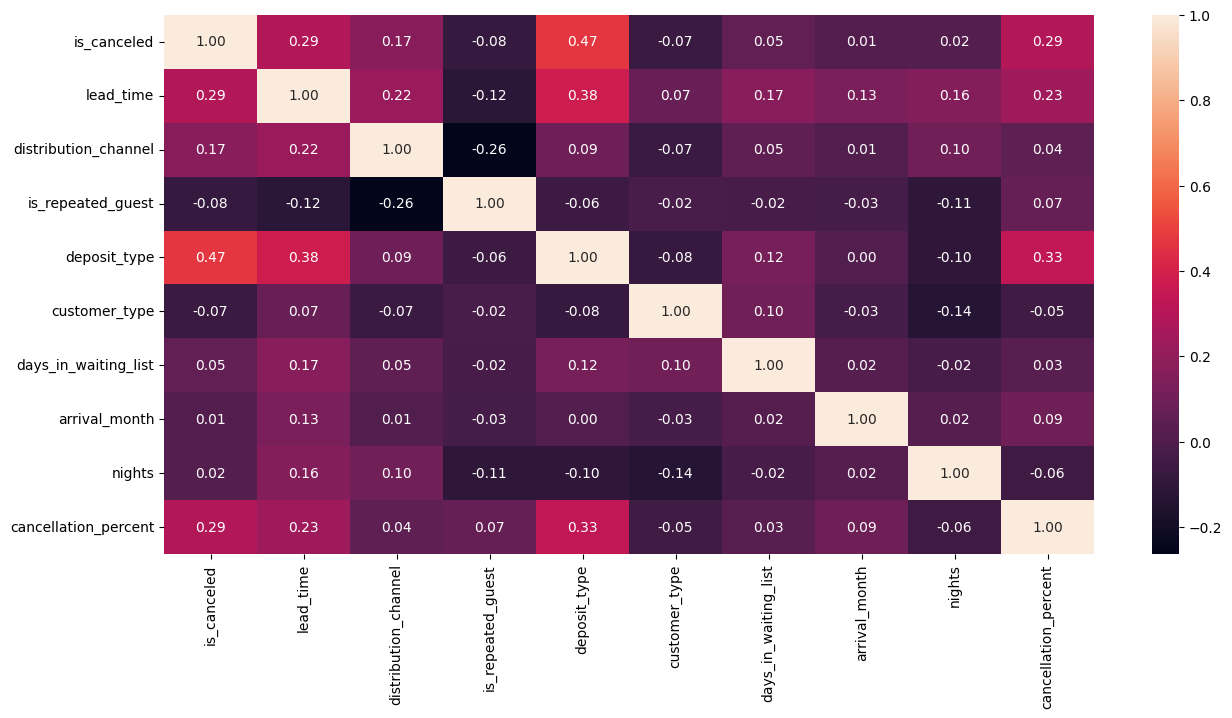

In [290]:
fig, ax = plt.subplots(figsize=(15,7))
sns.heatmap(bookings_nec.corr(method='pearson'), ax=ax, annot=True, fmt='.2f')

#### Отбор наиболее кореллирующих с is_cancelled признаков

In [291]:
bookings_prep = bookings_nec[["is_canceled", "lead_time", "deposit_type", 
                              "distribution_channel", "cancellation_percent"]]

#### Построение тренировочной и тестовой выборок

In [292]:
GPA_X_train, GPA_X_test, GPA_y_train, GPA_y_test = train_test_split(
    bookings_prep[["lead_time", "deposit_type", 
                              "distribution_channel", "cancellation_percent"]], 
    bookings_prep["is_canceled"], test_size=0.2, random_state=1)

#### Тренировка RandomForestClassifier

0.7690358784300176 0.23096412156998236


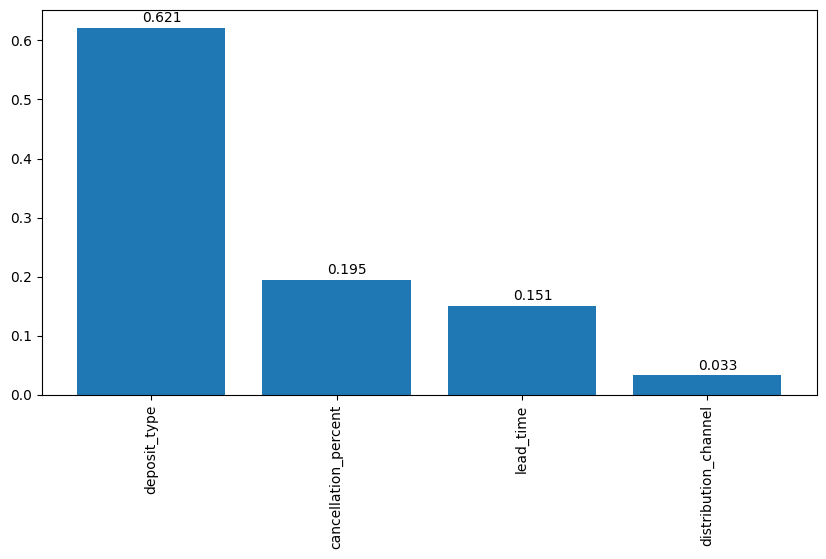

In [293]:
RANDOM_TREE_N_ESTIMATORS=25

random_tree = RandomForestClassifier(n_estimators=RANDOM_TREE_N_ESTIMATORS, oob_score=True, random_state=10, max_features='sqrt', min_samples_leaf=10, n_jobs=3)
random_tree.fit(GPA_X_train, GPA_y_train)

print(random_tree.oob_score_, 1-random_tree.oob_score_)
_,_ = draw_feature_importances(random_tree, GPA_X_train)


In [294]:
random_tree_estimator_partitions = []
n_jobs = 9

for i in range(n_jobs):
    if i == n_jobs - 1:
        random_tree_estimator_partitions.append(
            random_tree.estimators_[i*RANDOM_TREE_N_ESTIMATORS//n_jobs:RANDOM_TREE_N_ESTIMATORS])
    elif i == 0:
        random_tree_estimator_partitions.append(
            random_tree.estimators_[:(i+1)*RANDOM_TREE_N_ESTIMATORS//n_jobs])
    else:
        random_tree_estimator_partitions.append(
            random_tree.estimators_[i*RANDOM_TREE_N_ESTIMATORS//n_jobs:(i+1)*RANDOM_TREE_N_ESTIMATORS//n_jobs])
        
bookings_nec = Parallel(n_jobs=n_jobs)(delayed(render_png_trees)
                                       (random_tree_estimator_partitions[i], GPA_X_train.columns, 
                                        i*len(random_tree_estimator_partitions[i]), "renders/random_tree") 
                                        for i in range(len(random_tree_estimator_partitions)))

#### Тренировка DecisionTreeClassifier

In [295]:
tree_model = DecisionTreeClassifier(max_depth=20, 
                                   random_state=1, 
                                   min_samples_leaf=10, 
                                   criterion='gini', 
                                    max_features='sqrt')
tree_model.fit(GPA_X_train, GPA_y_train)
tree_y_pred = tree_model.predict(GPA_X_test)


In [296]:
render_png_tree(tree_model, GPA_X_train.columns, "tree_model", "renders/random_tree")

#### Вывод значений MAE и MSE для натренированных моделей

In [297]:
from sklearn.metrics import accuracy_score, f1_score


print(f"Accuracy для случайного дерева: {accuracy_score(GPA_y_test, random_tree.predict(GPA_X_test))}")
print(f"F1-мера для случайного дерева: {f1_score(GPA_y_test, random_tree.predict(GPA_X_test))}")
print(f"Accuracy для дерева решений: {accuracy_score(GPA_y_test, tree_model.predict(GPA_X_test))}")
print(f"F1-мера для дерева решений: {f1_score(GPA_y_test, tree_model.predict(GPA_X_test))}")

Accuracy для случайного дерева: 0.7715661641541038
F1-мера для случайного дерева: 0.5512873241753722
Accuracy для дерева решений: 0.7722361809045226
F1-мера для дерева решений: 0.5590595865423591


#### Выводы и объяснения
1. В данном случае были получены практически одинаковые значения для обеих моделей при том, что тренировка простога дерева решений прошла заметно быстрее (0,1с и 0,6с), хотя в общем случае должно быть наоборот.
2. Были выбраны Accuracy и F1-мера, поскольку первая дает наиболее простое и понятное описание, а вторая объединяет в себе Recall и Precision.